## Exploratory Data Analysis & Intro

#### Goal:
  
  1. Investigate top-paying roles and skills in the data science industry.  
  2. Use Python to explore a real-live dataset on job postings.
  3. For job-seekers: use these insights to help find the best job opportunities.  
  
#### Questions to Answer:
  
  1. What are the most demanded skills for the top 3 most popular data roles?
  2. How are in-demand skills trending for Data Analysts?
  3. How well do jobs and skills pay for Data Analysts?
  4. What is the most optimal skill to learn for Data Analysts? (High Demand AND High Paying) 

## Exploratory Data Analysis for all Data Roles

In [1]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


#loading data
df = pd.read_csv('data_jobs.csv')

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [2]:
print(df.info())
print(df.describe())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


In [3]:
df_DA_US = df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()
#df_DA_US['job_schedule_type'].value_counts()
df_DA_US[df_DA_US['job_schedule_type'].isin(['Full-time','Contractor','Part-time','Full-time and Part-time','Internship','Temp work','Volunteer'])]['job_schedule_type'].value_counts()

job_schedule_type
Full-time                  57180
Contractor                  6000
Full-time and Part-time      822
Part-time                    770
Internship                   618
Temp work                    305
Volunteer                      8
Name: count, dtype: int64

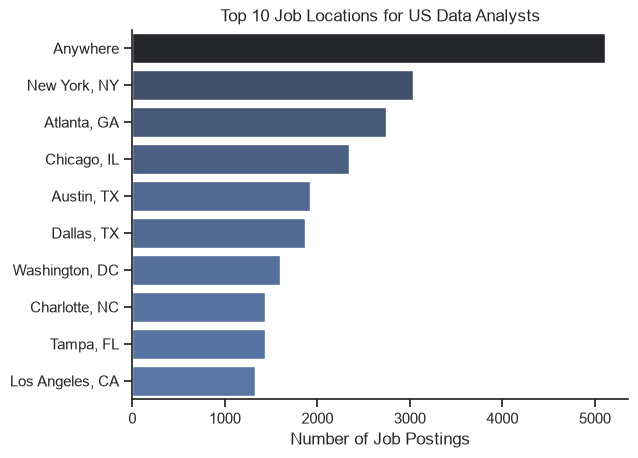

In [9]:
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data= df_plot,x='count',y='job_location',hue='count',palette='dark:b_r',legend=False)
plt.title('Top 10 Job Locations for US Data Analysts')
plt.xlabel('Number of Job Postings')
plt.ylabel('')
sns.despine()
plt.savefig(
    'images/EDA_job_locations.png',
    bbox_inches='tight',
    dpi=300
)
plt.show()

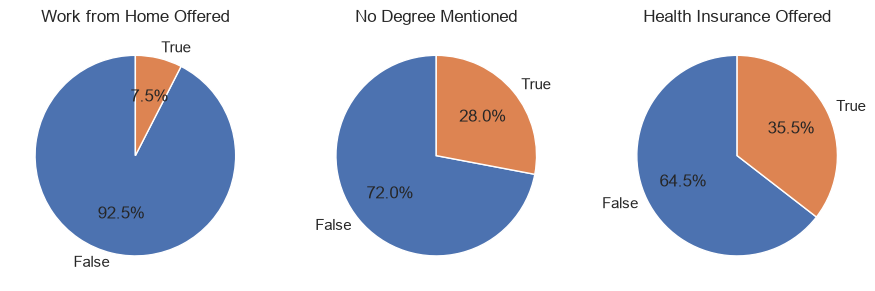

In [5]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'No Degree Mentioned',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))


for i, (column, title) in enumerate(dict_column.items()):
    counts = df_DA_US[column].value_counts().reindex([False, True])
    ax[i].pie(counts, labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

plt.show()

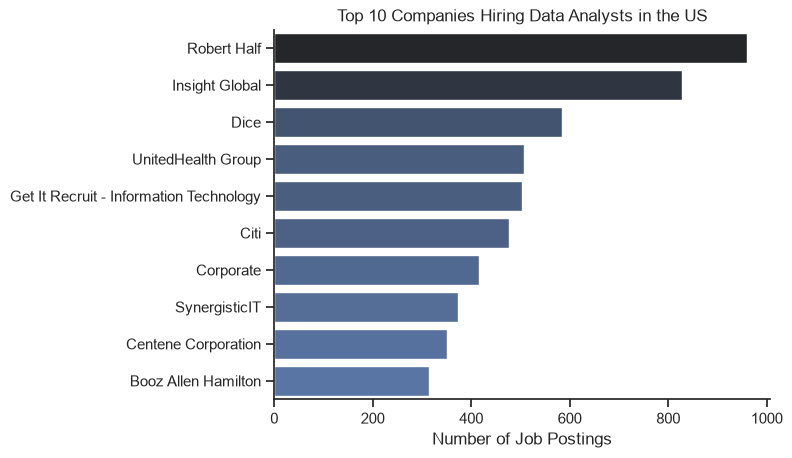

In [6]:
df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data= df_plot,x='count',y='company_name',hue='count',palette='dark:b_r',legend=False)
plt.title('Top 10 Companies Hiring Data Analysts in the US')
plt.xlabel('Number of Job Postings')
plt.ylabel('')
sns.despine()
plt.show()

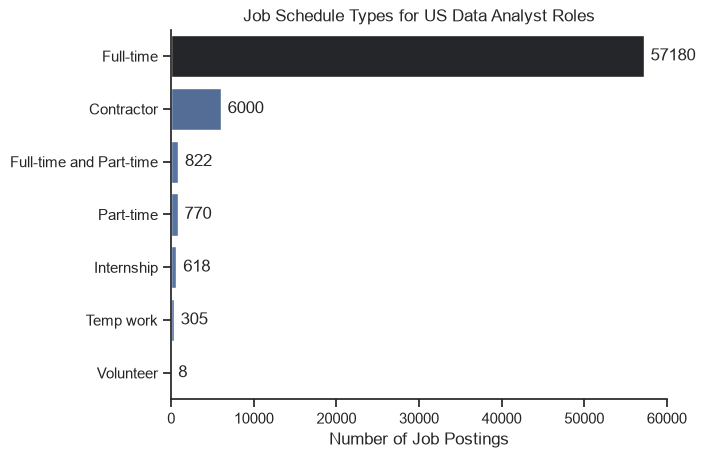

In [7]:

df_plot = df_DA_US[df_DA_US['job_schedule_type'].isin(['Full-time','Contractor','Part-time','Full-time and Part-time','Internship','Temp work','Volunteer'])]['job_schedule_type'].value_counts().to_frame()
sns.set_theme(style='ticks')
ax = sns.barplot(data= df_plot,x='count',y='job_schedule_type',hue='count',palette='dark:b_r',legend=False)
plt.title('Job Schedule Types for US Data Analyst Roles')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5)
plt.xlabel('Number of Job Postings')
plt.ylabel('')
sns.despine()
plt.show()